<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/image_caption_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (5).zip"  # apna filename check kar lena
extract_path = "/content/image-captioner"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [36]:
import numpy as np
import os
import pickle
import re
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [48]:
def load_captions(filename):
    captions = {}
    with open(filename, 'r') as f:
        next(f) # Skip header row (image,caption)
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 2:
                img_id = parts[0]
                caption = ','.join(parts[1:]) # Re-join if caption itself contains commas

                if img_id not in captions:
                    captions[img_id] = []
                captions[img_id].append(caption)
    return captions

captions = load_captions('/content/image-captioner/captions.txt')
print("Loaded captions:", len(captions))

Loaded captions: 8091


In [41]:
def clean_text(captions):
    for key in captions:
        cleaned = []
        for cap in captions[key]:
            cap = cap.lower()
            cap = re.sub(r'[^a-z ]', '', cap)
            cap = "startseq " + cap + " endseq"
            cleaned.append(cap)
        captions[key] = cleaned

clean_text(captions)

In [42]:
all_captions = []
for key in captions:
    all_captions.extend(captions[key])

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in all_captions)

print("Vocab size:", vocab_size)
print("Max length:", max_length)

Vocab size: 8781
Max length: 37


In [44]:
with open('/content/image-captioner/features.pkl', 'rb') as f:
    features = pickle.load(f)

print("Loaded features:", len(features))

Loaded features: 8091


In [45]:
def data_generator(captions, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = [], [], []

    while True:
        for img_id, caption_list in captions.items():
            feature = features[img_id][0]

            for caption in caption_list:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]

                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical(out_seq, num_classes=vocab_size)

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield ((np.array(X1), np.array(X2)), np.array(y))
                        X1, X2, y = [], [], []

In [49]:
def define_model(vocab_size, max_length):

    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(512, activation='relu')(fe1) # Changed from 256 to 512
    fe2 = BatchNormalization()(fe2)

    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(512)(se2)

    decoder1 = Add()([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)

    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.0005))

    return model

In [50]:
batch_size = 32
steps = len(captions) // batch_size

model = define_model(vocab_size, max_length)

generator = data_generator(captions, features, tokenizer, max_length, vocab_size, batch_size)

model.fit(generator, epochs=20, steps_per_epoch=steps)

Epoch 1/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 6.4288
Epoch 2/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5.7993
Epoch 3/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 5.6263
Epoch 4/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5.6493
Epoch 5/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.3603
Epoch 6/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5.4622
Epoch 7/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 5.1567
Epoch 8/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.1940
Epoch 9/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5.1490
Epoch 10/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 4.8414
Epoch 11/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 5.1018
Epoch 12/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.9099
Epoch 13/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.7954
Epoch 14/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 4.8205
Epoch 15/20
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s

In [51]:
def idx_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

In [52]:
def generate_caption_beam(model, tokenizer, photo, max_length, beam_index=3):

    start = [tokenizer.word_index['startseq']]
    sequences = [[start, 0.0]]

    while len(sequences[0][0]) < max_length:
        all_candidates = []

        for seq, score in sequences:
            padded = pad_sequences([seq], maxlen=max_length, padding='post')

            yhat = model.predict([photo, padded], verbose=0)
            yhat = np.log(yhat[0])

            top_words = np.argsort(yhat)[-beam_index:]

            for word in top_words:
                candidate = [seq + [word], score + yhat[word]]
                all_candidates.append(candidate)

        ordered = sorted(all_candidates, key=lambda tup: tup[1], reverse=True)
        sequences = ordered[:beam_index]

    final_seq = sequences[0][0]

    caption = []
    for i in final_seq:
        word = idx_to_word(i, tokenizer)
        if word == 'endseq':
            break
        if word != 'startseq':
            caption.append(word)

    return ' '.join(caption)

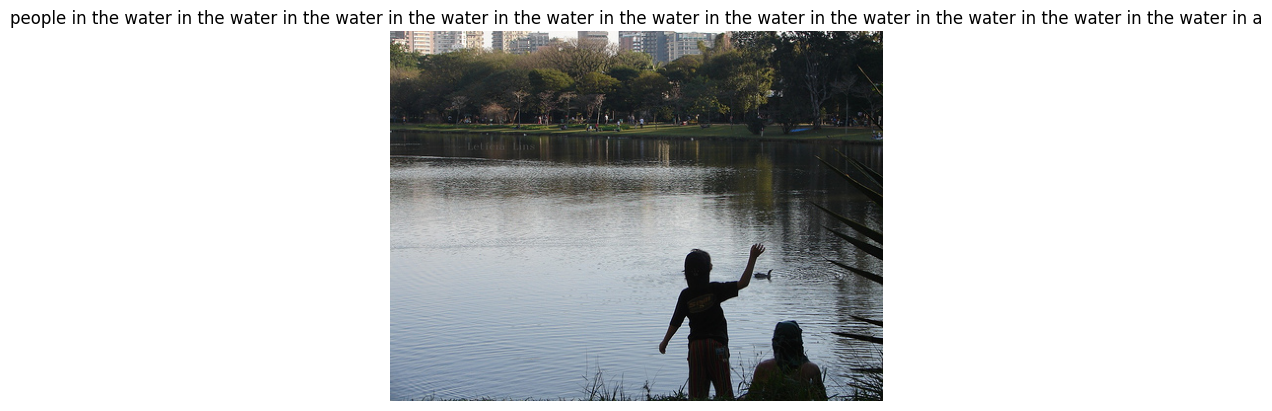

Caption: people in the water in the water in the water in the water in the water in the water in the water in the water in the water in the water in the water in a


In [56]:
img_id = '1022454332_6af2c1449a.jpg'

img_path = f"/content/image-captioner/Images/{img_id}"
img = Image.open(img_path)

photo = features[img_id]

caption = generate_caption_beam(model, tokenizer, photo, max_length, beam_index=5)

plt.imshow(img)
plt.title(caption)
plt.axis('off')
plt.show()

print("Caption:", caption)